### 한글 폰트 사용


In [22]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [23]:
import matplotlib.pyplot as plt
plt.rc("font", family="NanumGothic") # 라이브러리 불러오기와 함께 한번만 실행
plt.rcParams['axes.unicode_minus'] =False

### 구글 드라이브 연동

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 0. 데이터 불러오기 및 확인

In [2]:
import pandas as pd
onlinesales = pd.read_csv('/content/drive/MyDrive/데이터리안/Data/onlinesales.csv')
customer = pd.read_csv('/content/drive/MyDrive/데이터리안/Data/customer.csv')
titanic_train = pd.read_csv('/content/drive/MyDrive/데이터리안/Data/train.csv')
job = pd.read_csv('/content/drive/MyDrive/데이터리안/Data/job.csv')

In [3]:
onlinesales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    52924 non-null  object 
 1   order_id       52924 non-null  object 
 2   date           52924 non-null  object 
 3   product_id     52924 non-null  object 
 4   category       52924 non-null  object 
 5   quantity       52924 non-null  int64  
 6   avg_cost       52924 non-null  float64
 7   shipping_fee   52924 non-null  float64
 8   coupon_status  52924 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 3.6+ MB


In [4]:
onlinesales.describe()

,quantity,avg_cost,shipping_fee
count,52924.000000,52924.000000,52924.000000
mean,4.497638,52.237646,10.517630
std,20.104711,64.006882,19.475613
min,1.000000,0.390000,0.000000
25%,1.000000,5.700000,6.000000
50%,1.000000,16.990000,6.000000
75%,2.000000,102.130000,6.500000
max,900.000000,355.740000,521.360000


In [5]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  1468 non-null   object
 1   sex          1468 non-null   object
 2   local        1468 non-null   object
 3   period       1468 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 46.0+ KB


In [6]:
customer.describe()

,period
count,1468.000000
mean,25.912125
std,13.959667
min,2.000000
25%,14.000000
50%,26.000000
75%,38.000000
max,50.000000


In [7]:
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
titanic_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
import numpy as np
job['parents_id'] = job['parents_id'].replace(0, np.nan)

In [10]:
job.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          100 non-null    int64  
 1   job         100 non-null    object 
 2   parents_id  27 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.5+ KB


In [11]:
job.describe()

,id,parents_id
count,100.000000,27.000000
mean,457.850000,425.888889
std,248.578844,222.176356
min,9.000000,112.000000
25%,222.500000,217.500000
50%,488.500000,399.000000
75%,673.000000,605.500000
max,868.000000,868.000000


### 1. 데이터 연결하기2
- LEFT JOIN

In [12]:
job.head()

,id,job,parents_id
0,722,developer,714.0
1,11,police,547.0
2,818,firefighter,679.0
3,53,teacher,221.0
4,139,celebrity,175.0


In [13]:
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
# 승객과 관련된 모든 데이터 추출
combined_df = pd.merge(titanic_train, job, left_on = 'PassengerId', right_on = 'id', how = 'left')
combined_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,id,job,parents_id
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN,NaN,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,NaN,NaN,NaN
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN,NaN,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,NaN,NaN,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN,NaN,NaN


In [15]:
# 직업이 기재되어 있는 사람들만 추출
df_job = combined_df[combined_df['id'].isnull() == False ].reset_index(drop = True)
df_job.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,id,job,parents_id
0,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,9.0,teacher,699.0
1,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,11.0,police,547.0
2,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C,27.0,celebrity,NaN
3,47,0,3,"Lennon, Mr. Denis",male,NaN,1,0,370371,15.5000,NaN,Q,47.0,celebrity,165.0
4,52,0,3,"Nosworthy, Mr. Richard Cater",male,21.0,0,0,A/4. 39886,7.8000,NaN,S,52.0,police,691.0


In [16]:
# 성인(18세이상)이면서 직업이 기재되어 있는 사람들의 id, Age, job만 추출
df_adult = df_job[df_job['Age'] >= 18].reset_index(drop = True)
df_adult.loc[:4, ['id', 'Age', 'job']]

,id,Age,job
0,9.0,27.0,teacher
1,52.0,21.0,police
2,53.0,49.0,teacher
3,61.0,22.0,teacher
4,91.0,29.0,firefighter


- RIGHT JOIN

In [17]:
# 승객과 관련된 모든 데이터 추출
combined_df1 = pd.merge(job, titanic_train, left_on = 'id', right_on = 'PassengerId', how = 'right')
combined_df1.head()

,id,job,parents_id,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,NaN,NaN,NaN,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,NaN,NaN,NaN,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,NaN,NaN,NaN,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,NaN,NaN,NaN,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,NaN,NaN,NaN,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


- SELF JOIN

In [18]:
# job 테이블에서 자식과 부모가 같은 직업인 경우 확인
job_self_joined = pd.merge(job, job, left_on = 'parents_id', right_on = 'id', how = 'inner').reset_index(drop = True)
job_self_joined.head()

,id_x,job_x,parents_id_x,id_y,job_y,parents_id_y
0,722,developer,714.0,714,police,NaN
1,11,police,547.0,547,firefighter,NaN
2,818,firefighter,679.0,679,teacher,NaN
3,53,teacher,221.0,221,celebrity,NaN
4,139,celebrity,175.0,175,president,NaN


### 2. 매출 분석

In [19]:
# onlinesales 테이블의 일별 매출액 계산
# sales라는 매출 컬럼 생성
onlinesales['sales'] = onlinesales['quantity'] * onlinesales['avg_cost']

# 일별 매출액 계산
revenue_daily = onlinesales.groupby('date')['sales'].agg('sum').reset_index()
revenue_daily = revenue_daily.rename(columns = {'sales':'revenue_daily'})
revenue_daily.head()

,date,revenue_daily
0,2019-01-01,7380.49
1,2019-01-02,13438.47
2,2019-01-03,23834.21
3,2019-01-04,16603.41
4,2019-01-05,17373.19


In [20]:
# onlinesales 테이블의 일별 매출액, PU, ARPPU 계산
ARPPU = revenue_daily.copy()
ARPPU['PU'] = onlinesales.groupby('date')['customer_id'].agg('nunique').reset_index()['customer_id']
ARPPU.head()

,date,revenue_daily,PU
0,2019-01-01,7380.49,7
1,2019-01-02,13438.47,10
2,2019-01-03,23834.21,14
3,2019-01-04,16603.41,6
4,2019-01-05,17373.19,9


In [21]:
ARPPU['ARPPU'] = round(ARPPU['revenue_daily'] / ARPPU['PU'], 2)
ARPPU.head()

,date,revenue_daily,PU,ARPPU
0,2019-01-01,7380.49,7,1054.36
1,2019-01-02,13438.47,10,1343.85
2,2019-01-03,23834.21,14,1702.44
3,2019-01-04,16603.41,6,2767.24
4,2019-01-05,17373.19,9,1930.35


In [35]:
# date 컬럼 날짜 형식으로 변환
ARPPU['date'] = pd.to_datetime(ARPPU['date'])

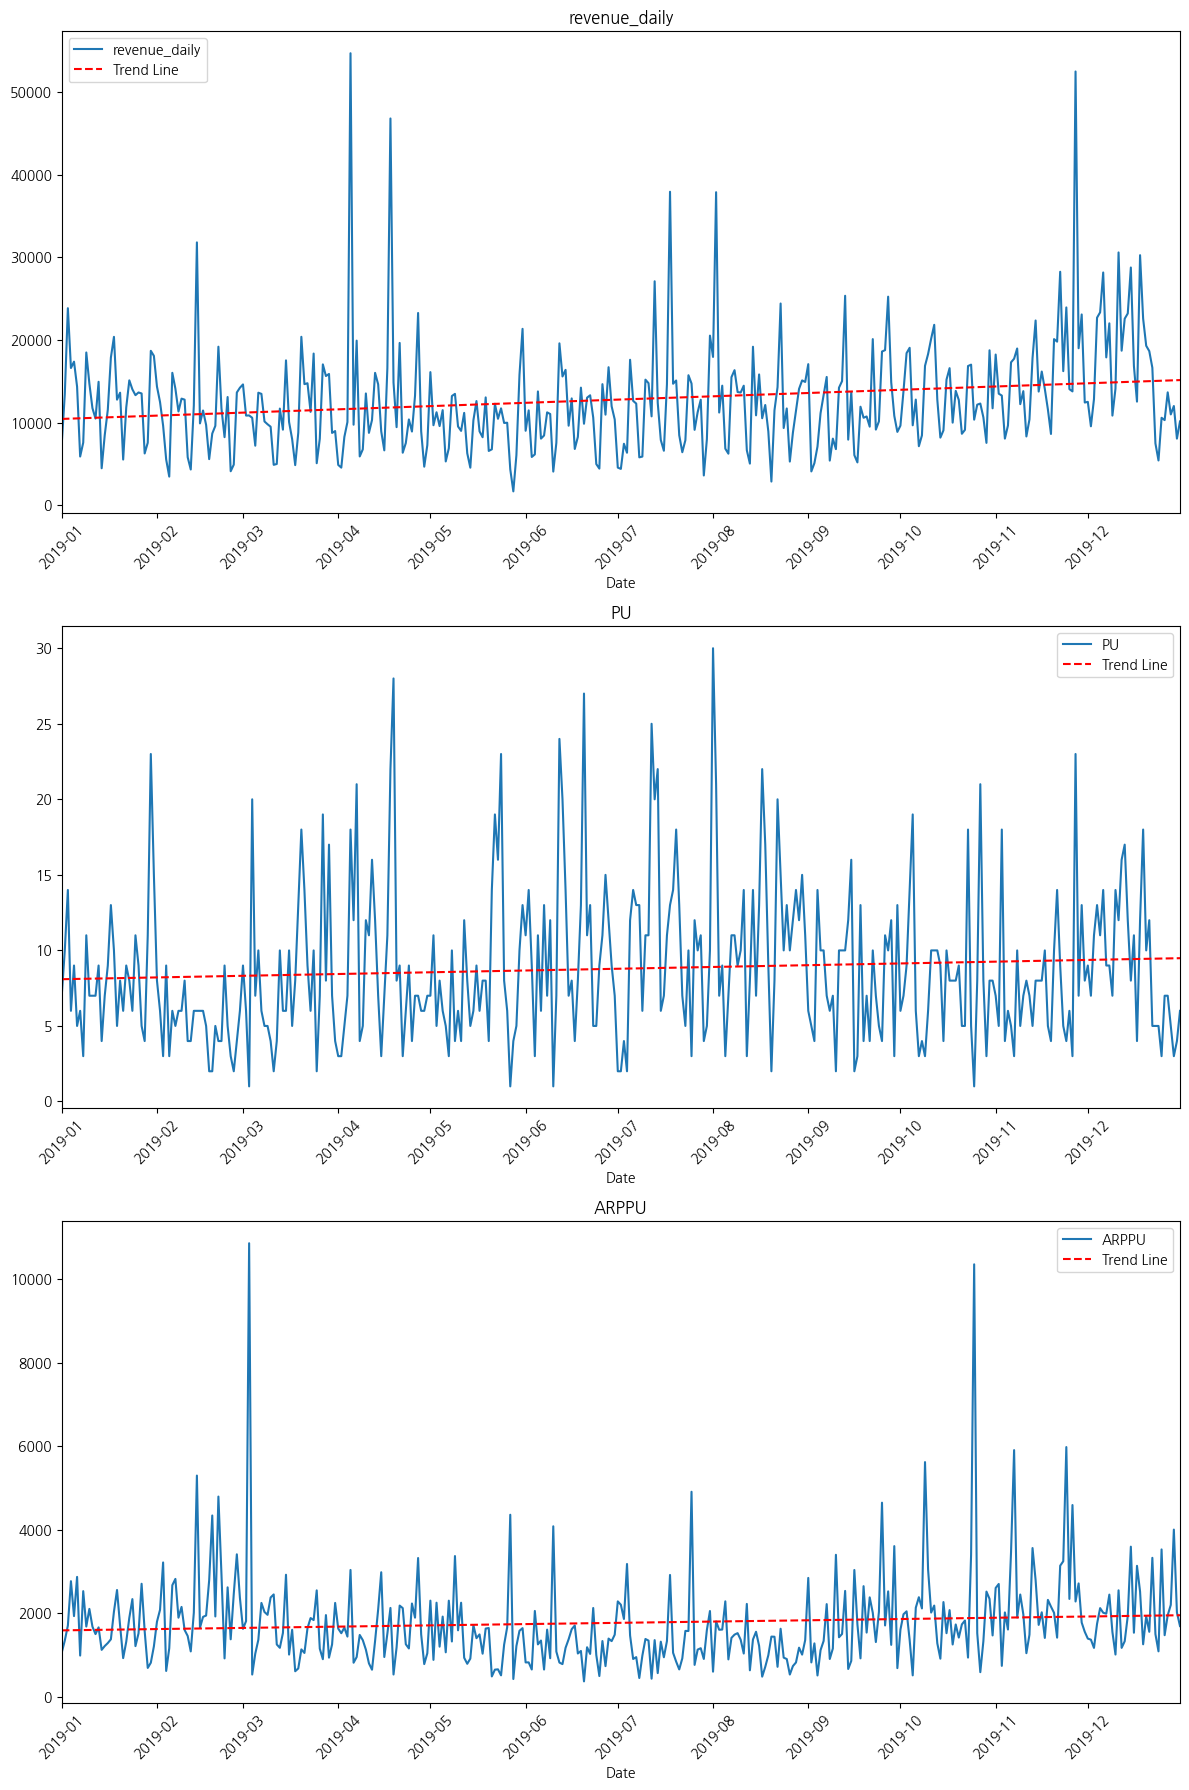

In [42]:
# matplotlib 라이브러리 사용
import matplotlib.dates as mdates

# 컬럼 리스트 정의
columns_to_plot = ['revenue_daily', 'PU', 'ARPPU']

# 그래프 크기 조정 및 서브플롯 생성
plt.figure(figsize=(12, 18))  # 전체 그래프 크기 설정

# 반복문을 통해 각각 그래프 그리기
for i, column in enumerate(columns_to_plot, start=1):
    plt.subplot(3, 1, i)  # 3행 1열의 i번째 서브플롯 생성
    plt.plot(ARPPU['date'], ARPPU[column], label=column)

    # 추세선 추가
    z = np.polyfit(mdates.date2num(ARPPU['date']), ARPPU[column], 1)  # 1차 다항식 (선형 회귀)
    p = np.poly1d(z)
    plt.plot(ARPPU['date'], p(mdates.date2num(ARPPU['date'])), "r--", label='Trend Line')  # 추세선

    # 그래프 제목 및 레이블 설정
    plt.title(f'{column}')
    plt.xlabel('Date')

    # x축 날짜 포맷 설정
    plt.xticks(rotation=45)  # x축 레이블 회전
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1, interval=1))  # 매달 1일
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # 연도와 월 포맷

    # x축 레이블 추가
    plt.xlim([ARPPU['date'].min(), ARPPU['date'].max()])  # x축 범위 설정

    plt.legend()  # 범례 추가

# 그래프 보여주기
plt.tight_layout()  # 레이아웃 조정
plt.show()

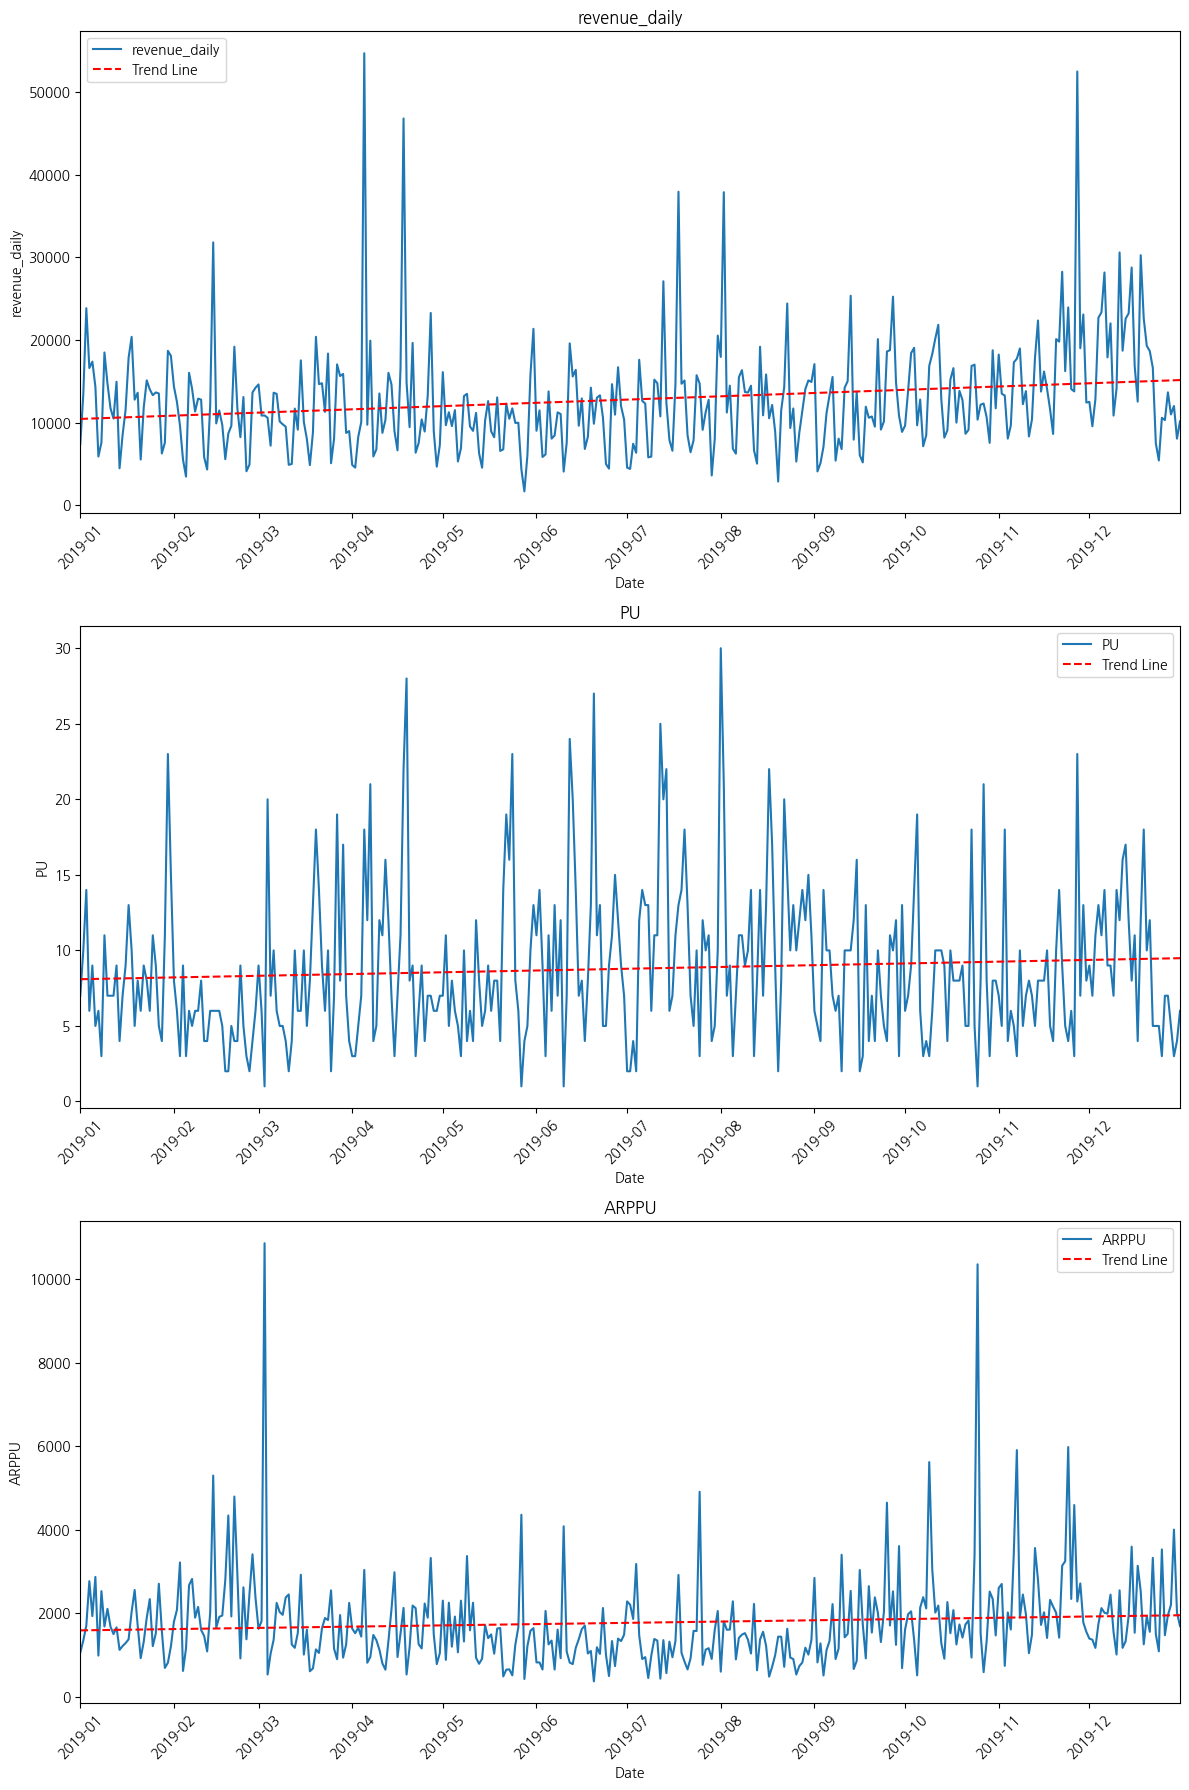

In [43]:
# seaborn 라이브러리 사용
import seaborn as sns

# 그래프 크기 조정
plt.figure(figsize=(12, 18))  # 전체 그래프 크기 설정

for i, column in enumerate(columns_to_plot, start=1):
    plt.subplot(3, 1, i)  # 3행 1열의 i번째 서브플롯 생성

    # Seaborn으로 선 그래프 그리기
    sns.lineplot(data=ARPPU, x='date', y=column, label=column)

    # 추세선 추가
    z = np.polyfit(mdates.date2num(ARPPU['date']), ARPPU[column], 1)  # 1차 다항식 (선형 회귀)
    p = np.poly1d(z)
    plt.plot(ARPPU['date'], p(mdates.date2num(ARPPU['date'])), "r--", label='Trend Line')  # 추세선

    # 그래프 제목 및 레이블 설정
    plt.title(f'{column}')
    plt.xlabel('Date')

    # x축 날짜 포맷 설정
    plt.xticks(rotation=45)  # x축 레이블 회전
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1, interval=1))  # 매달 1일
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # 연도와 월 포맷

    # x축 레이블 추가
    plt.xlim([ARPPU['date'].min(), ARPPU['date'].max()])  # x축 범위 설정
    plt.legend()  # 범례 추가

# 그래프 보여주기
plt.tight_layout()  # 레이아웃 조정
plt.show()

In [25]:
# 일별, 고객별 주문 금액 및 주문수
daily_customer_sales = onlinesales.groupby(['date', 'customer_id']).agg(
    revenue_per_customer = ('sales', 'sum'),
    order_cnts = ('order_id', 'nunique')
).reset_index()

# 결과 확인
daily_customer_sales.head(10)

,date,customer_id,revenue_per_customer,order_cnts
0,2019-01-01,USER_0066,821.68,5
1,2019-01-01,USER_0190,933.09,6
2,2019-01-01,USER_0345,1.24,1
3,2019-01-01,USER_0585,430.19,3
4,2019-01-01,USER_0683,153.71,1
5,2019-01-01,USER_0730,77.56,1
6,2019-01-01,USER_1358,4963.02,27
7,2019-01-02,USER_0025,1201.65,6
8,2019-01-02,USER_0541,31.35,1
9,2019-01-02,USER_0585,1847.15,10


In [26]:
# 지역별 1인당 매출액을 순위별로 추출
# 1단계: customer 데이터와 JOIN
local = pd.merge(onlinesales, customer, on = 'customer_id', how = 'inner')

# 2단계: 지역별로 매출, PU 구하기
df_l = local.groupby('local').agg(
    local_revenue = ('sales', 'sum'),
    PU = ('customer_id', 'nunique'),
).reset_index()
df_l

,local,local_revenue,PU
0,California,1442447.31,464
1,Chicago,1625885.58,456
2,New Jersey,409666.86,149
3,New York,937022.63,324
4,Washington DC,255772.24,75


In [27]:
# 3단계: LRPPU(Local Revenue Per Paying User) 계산해서 추가하기
df_l['LRPPU'] = df_l['local_revenue'] / df_l['PU']
df_l.sort_values('LRPPU', ascending = False)

,local,local_revenue,PU,LRPPU
1,Chicago,1625885.58,456,3565.538553
4,Washington DC,255772.24,75,3410.296533
0,California,1442447.31,464,3108.722651
3,New York,937022.63,324,2892.045154
2,New Jersey,409666.86,149,2749.442013


In [28]:
# Chicago 지역에서 제품 카테고리별 주문수, 매출
# 1단계: Chicago 지역 데이터만 따로 추출
df_chicago = local[local['local'] == 'Chicago'].reset_index(drop = True)
df_chicago.head()

,customer_id,order_id,date,product_id,category,quantity,avg_cost,shipping_fee,coupon_status,sales,sex,local,period
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,153.71,male,Chicago,12
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,153.71,male,Chicago,12
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,2.05,male,Chicago,12
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,87.65,male,Chicago,12
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,16.50,male,Chicago,12


In [29]:
# 2단계: 제품 카테고리별 주문수, 매출액 구하기
df_chicago = df_chicago.groupby('category').agg(
    order_cnts = ('order_id', 'nunique'),
    revenue_category = ('sales', 'sum')
).reset_index()
df_chicago.sort_values('revenue_category', ascending = False).reset_index(drop = True).head()

,category,order_cnts,revenue_category
0,Nest-USA,4082,882041.55
1,Apparel,2906,214975.27
2,Nest,650,162722.10
3,Office,1304,95550.95
4,Drinkware,929,76220.24
